In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mxlpy import Model, Simulator, make_protocol
import sys
import os

sys.path.append(os.path.abspath('..'))

from model import Davis2017


In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [5]:
m = Davis2017()

y0 = {
 'QA_red': 1.1901157857510195e-06,
 'PQH_2': 0.0014287448543971206,
 'pH_lumen': 6.455811359293984,
 'Dpsi': 0.014085521658351582,
 'K_lu': 0.02332085422554469,
 'PC_ox': 1.9255808934834522,
 'Zx': 0.07336821501904481,
 'singO2': 0.43293396566528836,
 'P700_ox': 0,
 'Fd_red': 0,
 'NADPH_st': 0,
 'LEF': 0,
 'ATP_made': 0
 }

s_zero = Simulator(m).update_variables(y0).update_parameter("P_K",0)

protocol = make_protocol([
    (60, {'PPFD': 0}),
    (300, {'PPFD': 300}),
    (600, {'PPFD': 0}),
])
zero = s_zero.simulate_protocol(protocol, time_points_per_step=10000).get_result().unwrap_or_err().get_combined()


In [6]:
m = Davis2017()

y0 = {
 'QA_red': 5.511496362768013e-06,
 'PQH_2': 0.006610917859794705,
 'pH_lumen': 6.455489733520293,
 'Dpsi': 0.014066213897372587,
 'K_lu': 0.023314403407362544,
 'PC_ox': 1.6965704506492556,
 'Zx': 0.0735694070105809,
 'singO2': 0.38023965479069094,
 'P700_ox': 0,
 'Fd_red': 0,
 'NADPH_st': 0,
 'LEF': 0,
 'ATP_made': 0
 }

s_norm = Simulator(m).update_variables(y0)

protocol = make_protocol([
    (60, {'PPFD': 0}),
    (300, {'PPFD': 300}),
    (600, {'PPFD': 0}),
])
norm = s_norm.simulate_protocol(protocol, time_points_per_step=10000).get_result().unwrap_or_err().get_combined()


In [7]:
m = Davis2017()

y0 = {
 'QA_red': 1.6680442448215374e-05,
 'PQH_2': 0.01996349863700503,
 'pH_lumen': 6.455422734896244,
 'Dpsi': 0.014062169675170863,
 'K_lu': 0.023317976223034567,
 'PC_ox': 1.2976782989183835,
 'Zx': 0.07361151276346266,
 'singO2': 0.2874820769637723,
 'P700_ox': 0,
 'Fd_red': 0,
 'NADPH_st': 0,
 'LEF': 0,
 'ATP_made': 0
 }

s_fast = Simulator(m).update_variables(y0).update_parameter("P_K",60000)

protocol = make_protocol([
    (60, {'PPFD': 0}),
    (300, {'PPFD': 300}),
    (600, {'PPFD': 0}),
])
fast = s_fast.simulate_protocol(protocol, time_points_per_step=10000).get_result().unwrap_or_err().get_combined()


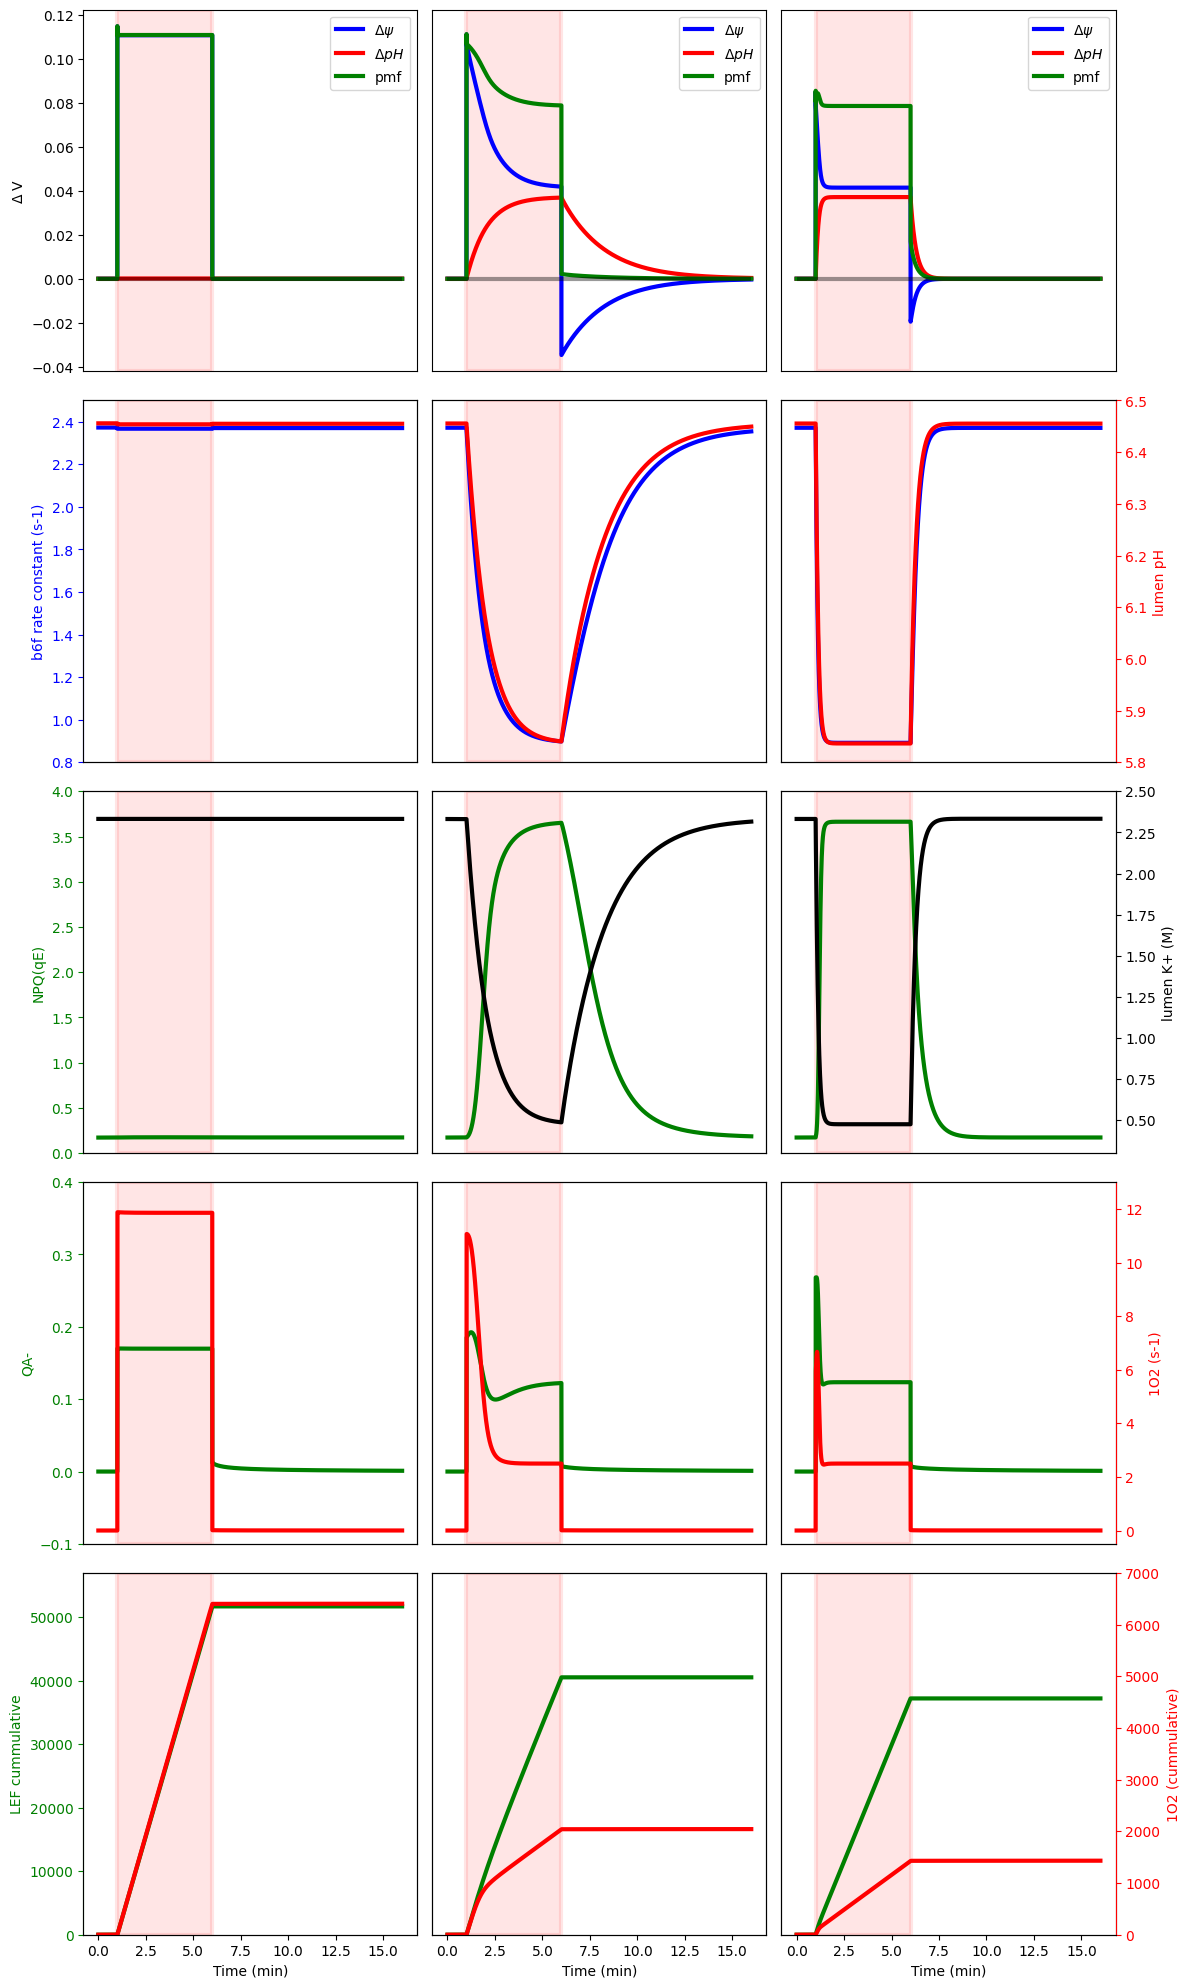

In [36]:
pmf_name = [
    ['Dpsi', "delta_pH_inVolts", 'pmf',], 
    ['k_b6f'],
    ['NPQ'],
    ['QA_red'],
    ['LEF'],
    ["vATPsynthase", "v_VKC", "v_KEA3", "PSI_ChSep", "vPSII_ChSep", "vPSII_recomb", "v_b6f"]
    ]

labels = {
    "Dpsi": r"$\Delta \psi$",
    "delta_pH_inVolts": r"$\Delta pH$",
    "pmf": "pmf"
}

colors = {
    "Dpsi": "blue",
    "delta_pH_inVolts": "red",
    "pmf": "green"
}

nrows = 5

fig, axs = plt.subplots(ncols=3, nrows=nrows, figsize= (12, 4*nrows), sharey="row")

row = axs[0,:]
for ax, df in zip(row.flatten(), [zero, norm, fast]):
    for k in ["Dpsi", "delta_pH_inVolts", "pmf"]:
        ax.plot(df.index/60,df[k] - df[k][0],  label = labels[k], linewidth=3,color = colors[k])
    ax.legend()
        # ax.set_ylim(-0.05, 0.3)
    ax.axvspan(1,6, linewidth=3,color="red", alpha = 0.1)
    ax.hlines(0,0, 16, linewidth=3,color="black", alpha = 0.4)
row[0].set_ylabel(r"$\Delta$ V")

row = axs[1,:]
for ax, df in zip(row.flatten(), [zero, norm, fast]):
    ax.plot(df.index/60,df["k_b6f"]*5, linewidth=3,color = "blue")
    ax.set_ylim(0.8, 2.5)
    ax.axvspan(1,6, linewidth=3,color="red", alpha = 0.1)

    axx = ax.twinx()
    axx.plot(df.index/60,df["pH_lumen"], linewidth=3,color = "red")
    axx.set_ylim(5.8, 6.5)
    axx.tick_params(
    axis='both',
    which='both',
    right=False,
    labelright=False) 
row[0].set_ylabel("b6f rate constant (s-1)", color = "blue")
ax.tick_params(
    axis='both',
    which='both',
    left=False,
    labelleft=False,
    bottom=False,
    labelbottom=False) 

axx.set_ylabel("lumen pH", color = "red")
axx.tick_params(
    axis='y',
    which='both',
    right=True,
    labelright=True,
    color ="red",
    labelcolor = "red") 
axx.spines['right'].set_color('red')

row = axs[2,:]
for ax, df in zip(row.flatten(), [zero, norm, fast]):
    ax.plot(df.index/60,df["NPQ"], linewidth=3,color = "green")
    ax.set_ylim(0, 4)
    ax.axvspan(1,6, linewidth=3,color="red", alpha = 0.1)

    axx = ax.twinx()
    axx.plot(df.index/60,df["K_lu"]*100, linewidth=3,color = "black")
    axx.set_ylim(0.3, 2.5)
    axx.tick_params(
    axis='both',
    which='both',
    right=False,
    labelright=False,) 
row[0].set_ylabel("NPQ(qE)")
axx.set_ylabel("lumen K+ (M)")
axx.tick_params(
    axis='y',
    which='both',
    right=True,
    labelright=True)

row = axs[3,:]
for ax, df in zip(row.flatten(), [zero, norm, fast]):
    ax.plot(df.index/60,df["QA_red"]/2, linewidth=3,color = "green")
    ax.set_ylim(-0.1, 0.4)
    ax.axvspan(1,6, linewidth=3,color="red", alpha = 0.1)

    axx = ax.twinx()
    axx.plot(df.index/60,df["vPSII_recomb"]/4, linewidth=3,color = "red")
    axx.set_ylim(-0.5, 13)
    axx.tick_params(
    axis='both',
    which='both',
    right=False,
    labelright=False) 
row[0].set_ylabel("QA-")
axx.set_ylabel("1O2 (s-1)", color ="red")
axx.tick_params(
    axis='y',
    which='both',
    right=True,
    labelright=True,
    color ="red",
    labelcolor = "red") 
axx.spines['right'].set_color('red')

row = axs[4,:]
for ax, df in zip(row.flatten(), [zero, norm, fast]):
    ax.plot(df.index/60,df["LEF"], linewidth=3,color = "green")
    ax.set_ylim(0, 57000)
    ax.axvspan(1,6, linewidth=3,color="red", alpha = 0.1)

    axx = ax.twinx()
    axx.plot(df.index/60,df["singO2"], linewidth=3,color = "red")
    axx.set_ylim(0, 7000)
    axx.tick_params(
    axis='both',
    which='both',
    right=False,
    labelright=False) 
row[0].set_ylabel("LEF cummulative")
axx.set_ylabel("1O2 (cummulative)", color ="red")
axx.tick_params(
    axis='y',
    which='both',
    right=True,
    labelright=True,
    color ="red",
    labelcolor = "red") 
axx.spines['right'].set_color('red')

for ax in axs.flatten():
    ax.tick_params(
    which='both',
    left=False,
    labelleft=False,
    bottom=False,
    labelbottom=False) 

for ax, color in zip(axs[:,0].flatten(), ["black", "blue", "green", "green", "green"]):
    ax.tick_params(
    which='both',
    left=True,
    labelleft=True,
    color =color,
    labelcolor = color) 
    ax.spines['left'].set_color(color)
    ax.yaxis.label.set_color(color)

for ax in axs[-1:,].flatten():
    ax.tick_params(
    axis = "x",
    which='both',
    bottom=True,
    labelbottom=True,
    color ="black",
    labelcolor = "black") 
    ax.set_xlabel("Time (min)")

plt.tight_layout()
plt.savefig("Figure3.png")
plt.show()

<Axes: >

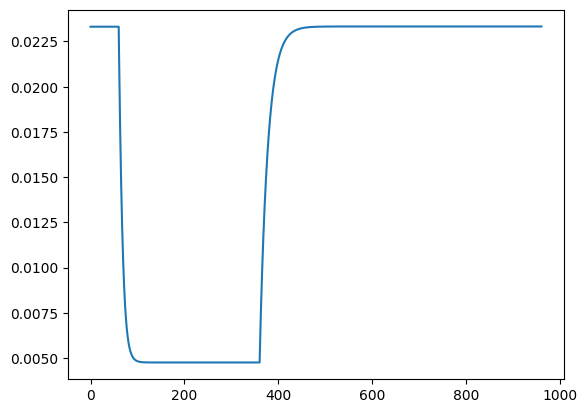

In [9]:
df["K_lu"].plot()

In [10]:
df["k_b6f"]

0.000      0.474362
0.006      0.474362
0.012      0.474362
0.018      0.474362
0.024      0.474362
0.030      0.474362
0.036      0.474362
0.042      0.474362
0.048      0.474362
0.054      0.474362
0.060      0.474362
0.066      0.474362
0.072      0.474362
0.078      0.474362
0.084      0.474362
0.090      0.474362
0.096      0.474362
0.102      0.474362
0.108      0.474362
0.114      0.474362
0.120      0.474362
0.126      0.474362
0.132      0.474362
0.138      0.474362
0.144      0.474362
0.150      0.474362
0.156      0.474362
0.162      0.474362
0.168      0.474362
0.174      0.474362
0.180      0.474362
0.186      0.474362
0.192      0.474362
0.198      0.474362
0.204      0.474362
0.210      0.474362
0.216      0.474362
0.222      0.474362
0.228      0.474362
0.234      0.474362
0.240      0.474362
0.246      0.474362
0.252      0.474362
0.258      0.474362
0.264      0.474362
0.270      0.474362
0.276      0.474362
0.282      0.474362
0.288      0.474362
0.294      0.474362


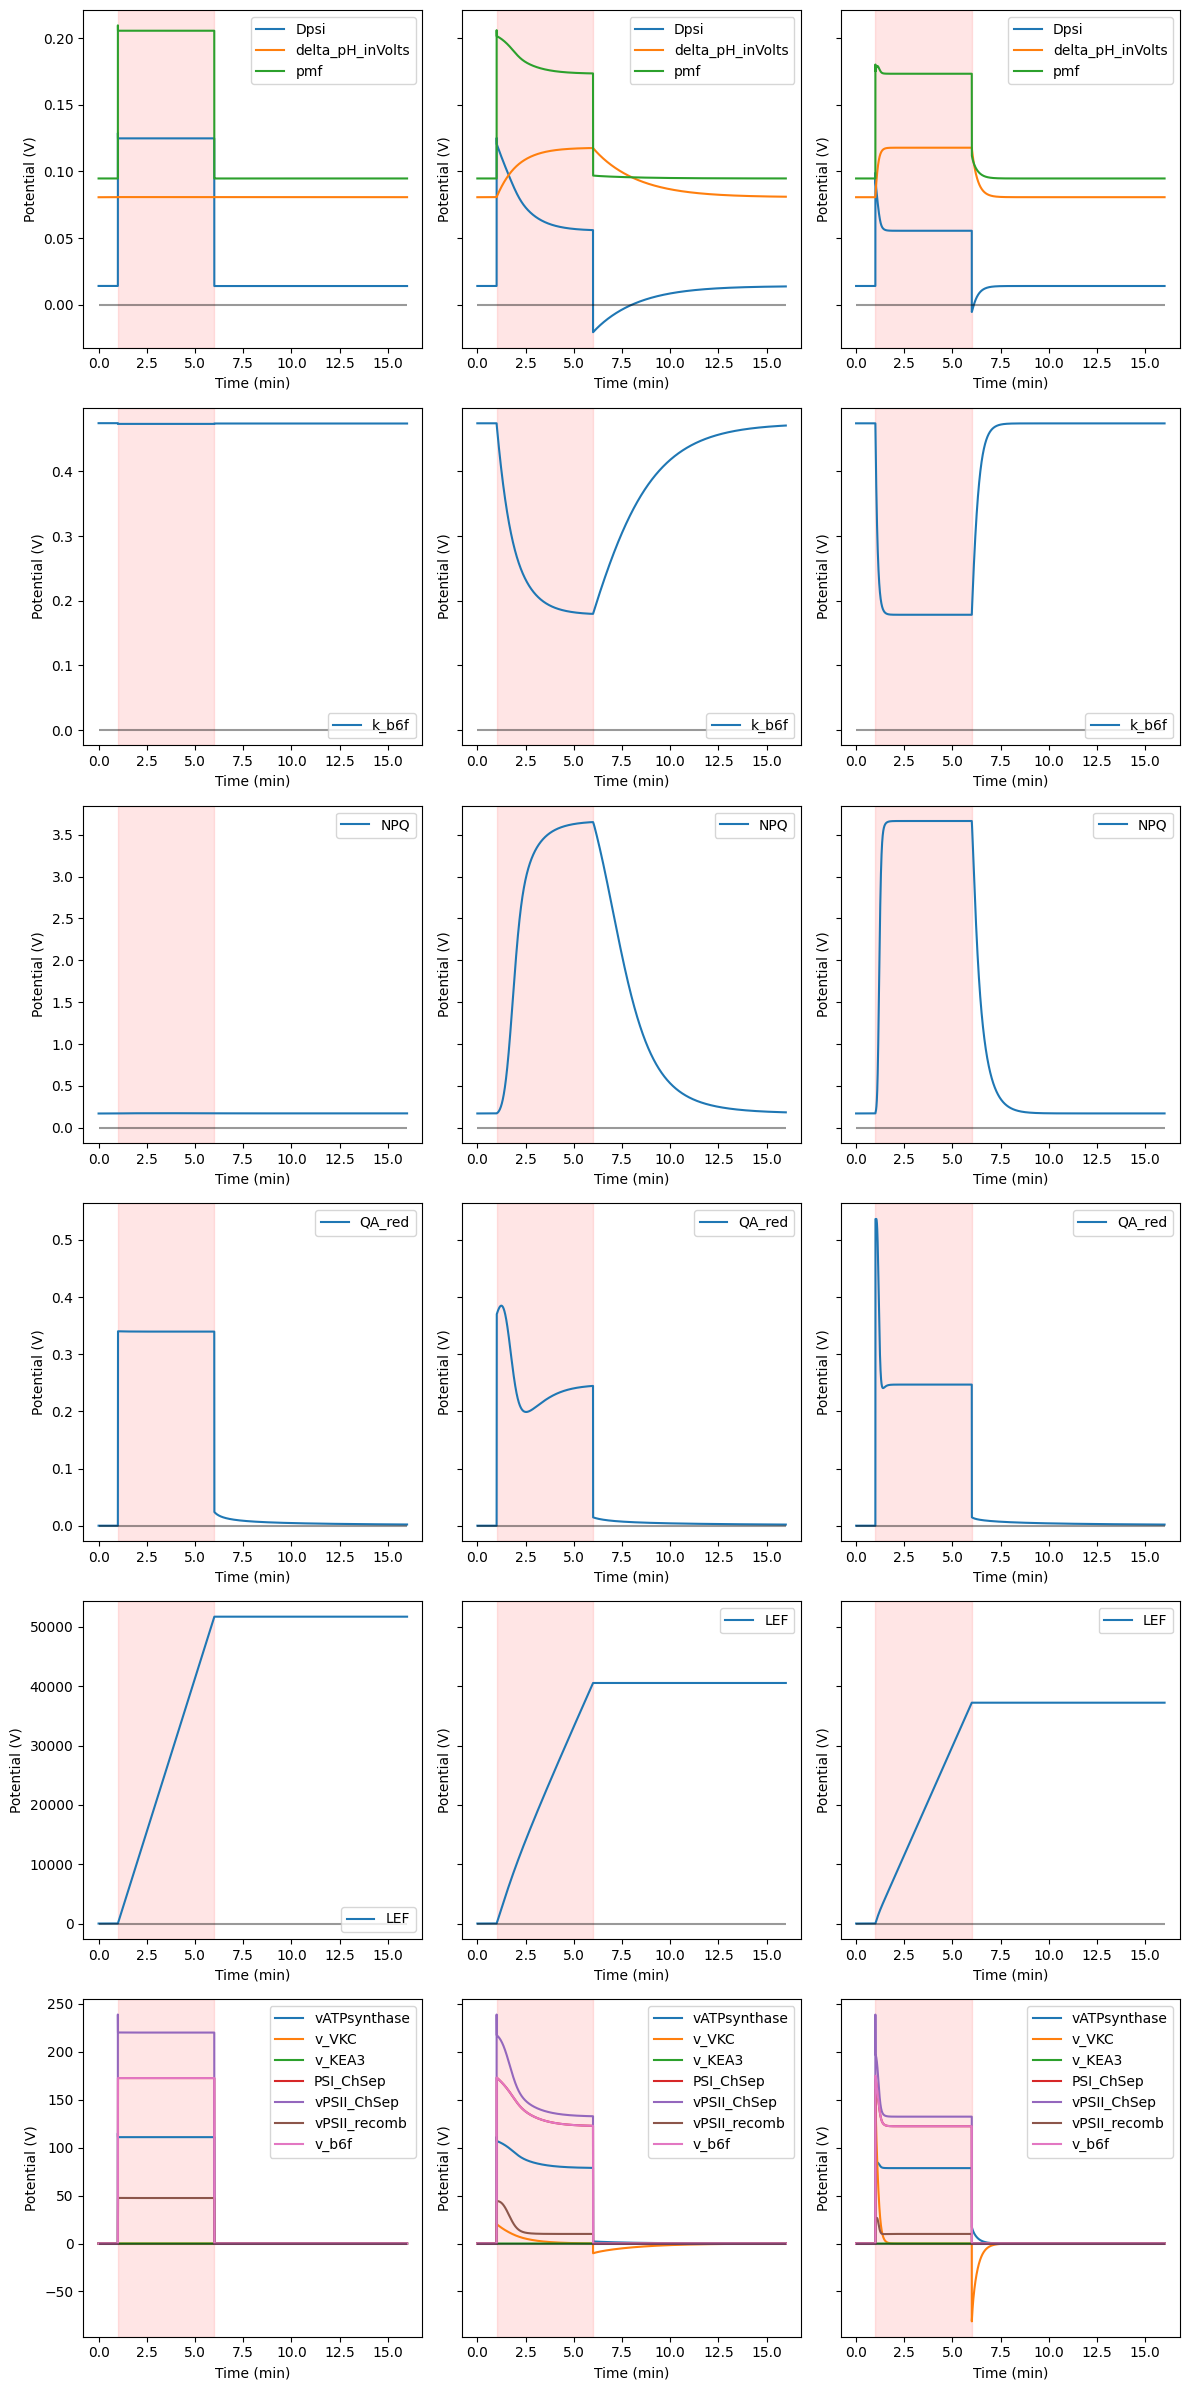

In [11]:
pmf_name = [
    ['Dpsi', "delta_pH_inVolts", 'pmf',], 
    ['k_b6f'],
    ['NPQ'],
    ['QA_red'],
    ['LEF'],
    ["vATPsynthase", "v_VKC", "v_KEA3", "PSI_ChSep", "vPSII_ChSep", "vPSII_recomb", "v_b6f"]
    ]

nrows = len(pmf_name)

fig, axs = plt.subplots(ncols=3, nrows=nrows, figsize= (12, 4*nrows), sharey='row')

if nrows == 1:
    row = axs
    for ax, df in zip(row.flatten(), [zero, norm, fast]):
        for k in pmf_name:
            ax.plot(df.index/60,df[k],  label = k)
        ax.set_ylabel('Potential (V)')
        ax.set_xlabel('Time (min)')
        ax.legend()
        # ax.set_ylim(-0.05, 0.3)
        ax.axvspan(1,6, color='red', alpha = 0.1)
        ax.hlines(0,0, 16, color='black', alpha = 0.4)
else:
    for i, set in zip(range(nrows), pmf_name):
        row = axs[i, :]
        for ax, df in zip(row.flatten(), [zero, norm, fast]):
            for k in set:
                ax.plot(df.index/60,df[k],  label = k)
            ax.set_ylabel('Potential (V)')
            ax.set_xlabel('Time (min)')
            ax.legend()
            # ax.set_ylim(-0.05, 0.3)
            ax.axvspan(1,6, color='red', alpha = 0.1)
            ax.hlines(0,0, 16, color='black', alpha = 0.4)

plt.tight_layout()

In [12]:
7.8 - 0.09/0.06

6.3